#Lab Sheet - 03

Name - Saurabh Kumar Jha

Section - B, Roll.No. 53

CU ID - CU240251681

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
import cv2

image = cv2.imread("/content/image.jpg")

print("Image loaded successfully!")
print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (3264, 4080, 3)


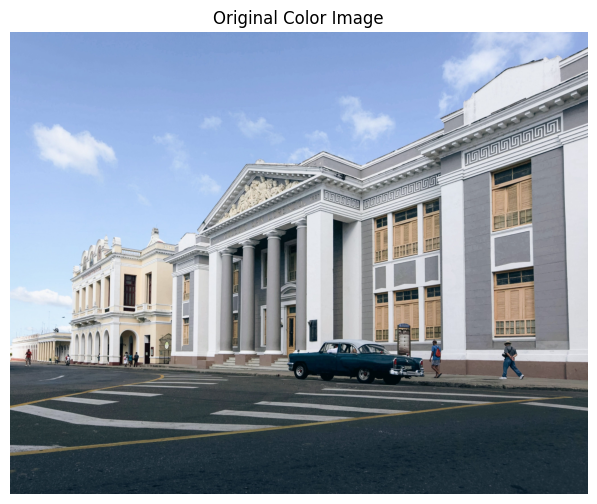

In [9]:
plt.figure(figsize=(8, 6))

# OpenCV loads images in BGR format, so convert BGR to RGB
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(original_rgb)
plt.title("Original Color Image")
plt.axis("off")

plt.show()

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Image converted to grayscale!")
print("Grayscale image shape:", gray.shape)

Image converted to grayscale!
Grayscale image shape: (3264, 4080)


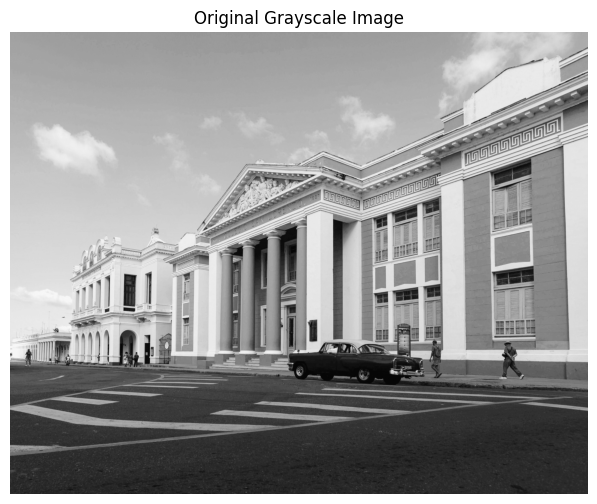

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.show()

In [10]:
start = time.perf_counter()

gaussian = cv2.GaussianBlur(gray, (5, 5), 0)

gaussian_time = time.perf_counter() - start

print("Gaussian filtering completed.")
print("Time taken:", gaussian_time, "seconds")

Gaussian filtering completed.
Time taken: 0.027050279000036426 seconds


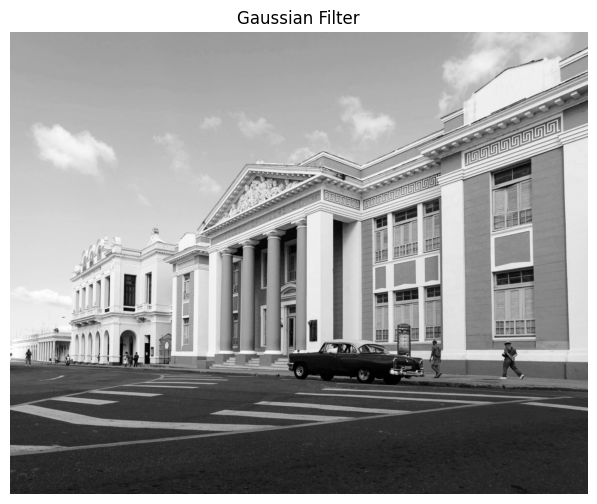

In [11]:
plt.figure(figsize=(8, 6))

plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

In [12]:
start = time.perf_counter()

median = cv2.medianBlur(gray, 5)

median_time = time.perf_counter() - start

print("Median filtering completed.")
print("Time taken:", median_time, "seconds")

Median filtering completed.
Time taken: 0.0251308770000378 seconds


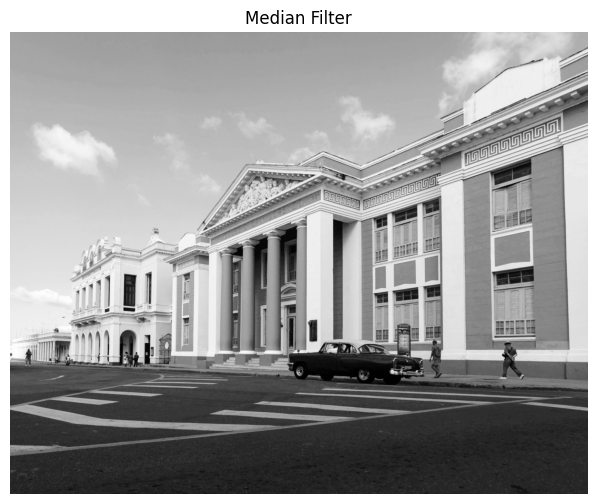

In [13]:
plt.figure(figsize=(8, 6))

plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.show()

In [14]:
noisy = gray.copy()

noise_amount = 0.05
num_pixels = int(noise_amount * noisy.size)

# Add salt noise
coords = (
    np.random.randint(0, noisy.shape[0], num_pixels),
    np.random.randint(0, noisy.shape[1], num_pixels)
)
noisy[coords] = 255

# Add pepper noise
coords = (
    np.random.randint(0, noisy.shape[0], num_pixels),
    np.random.randint(0, noisy.shape[1], num_pixels)
)
noisy[coords] = 0

print("Salt-and-pepper noise added.")

Salt-and-pepper noise added.


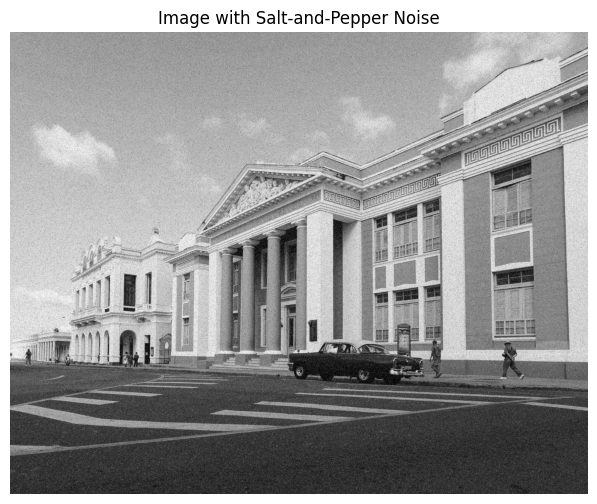

In [15]:
plt.figure(figsize=(8, 6))

plt.imshow(noisy, cmap="gray")
plt.title("Image with Salt-and-Pepper Noise")
plt.axis("off")

plt.show()

In [16]:
start = time.perf_counter()

median_noisy = cv2.medianBlur(noisy, 5)

median_noisy_time = time.perf_counter() - start

print("Median filtering of noisy image completed.")
print("Time taken:", median_noisy_time, "seconds")

Median filtering of noisy image completed.
Time taken: 0.021801666999976987 seconds


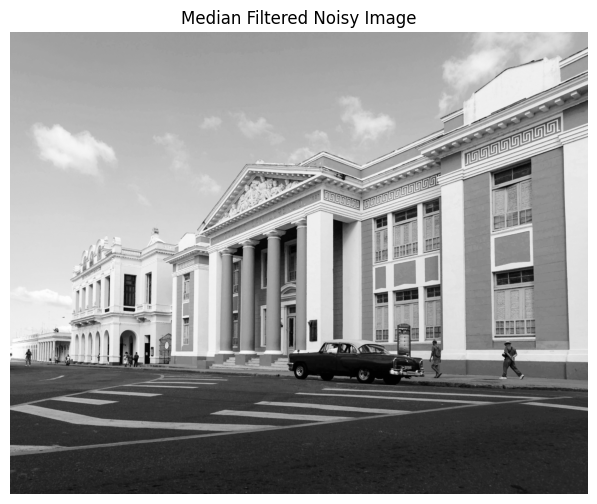

In [17]:
plt.figure(figsize=(8, 6))

plt.imshow(median_noisy, cmap="gray")
plt.title("Median Filtered Noisy Image")
plt.axis("off")

plt.show()

In [18]:
start = time.perf_counter()

average = cv2.blur(gray, (5, 5))

average_time = time.perf_counter() - start

print("Average filtering completed.")
print("Time taken:", average_time, "seconds")

Average filtering completed.
Time taken: 0.019980802999953085 seconds


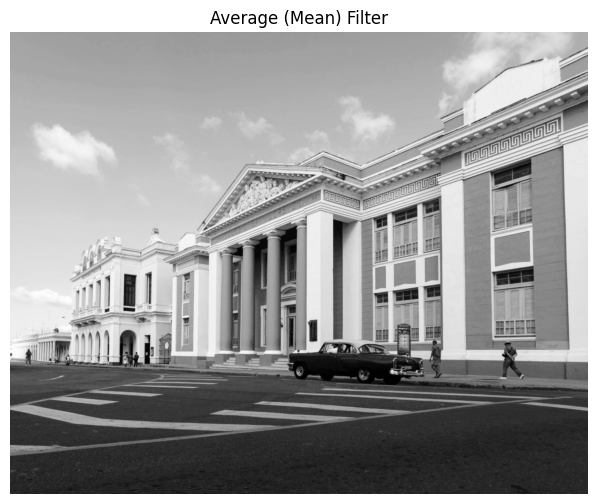

In [19]:
plt.figure(figsize=(8, 6))

plt.imshow(average, cmap="gray")
plt.title("Average (Mean) Filter")
plt.axis("off")

plt.show()

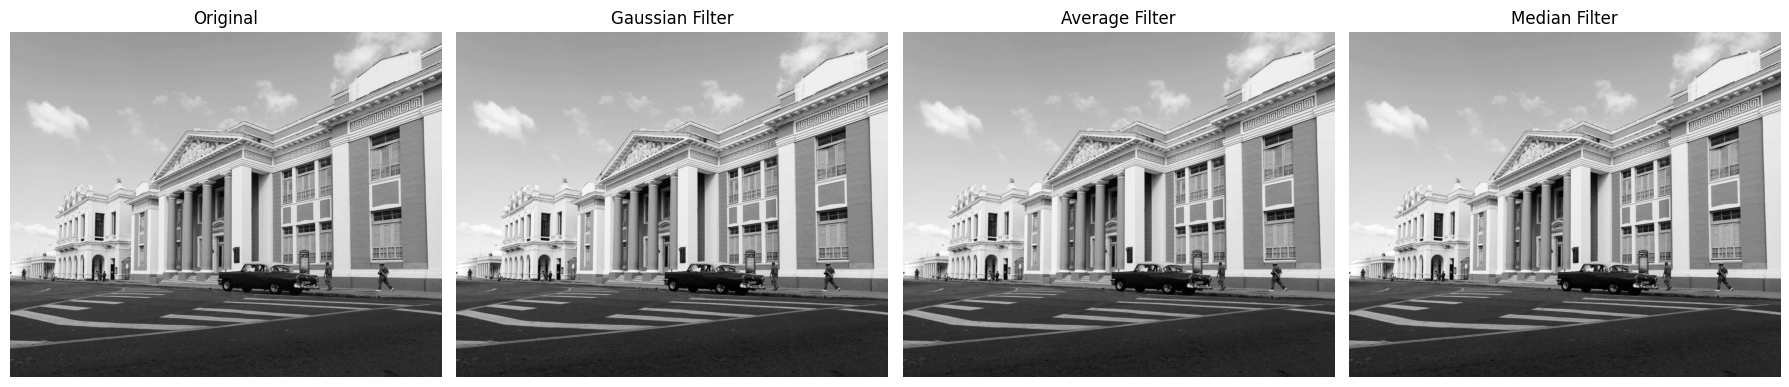

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gaussian, cmap="gray")
axes[1].set_title("Gaussian Filter")
axes[1].axis("off")

axes[2].imshow(average, cmap="gray")
axes[2].set_title("Average Filter")
axes[2].axis("off")

axes[3].imshow(median, cmap="gray")
axes[3].set_title("Median Filter")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [21]:
start = time.perf_counter()

laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Convert negative values to positive magnitudes
laplacian = np.absolute(laplacian)

# Convert to displayable 8-bit image
laplacian = np.uint8(np.clip(laplacian, 0, 255))

laplacian_time = time.perf_counter() - start

print("Laplacian filtering completed.")
print("Time taken:", laplacian_time, "seconds")

Laplacian filtering completed.
Time taken: 0.21679947500001617 seconds


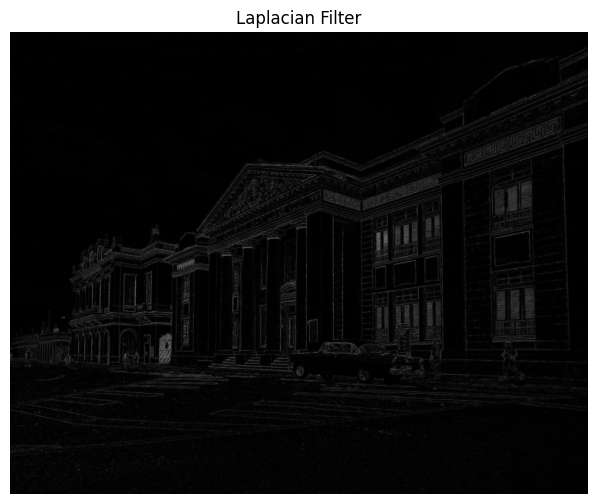

In [22]:
plt.figure(figsize=(8, 6))

plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Filter")
plt.axis("off")

plt.show()

In [23]:
start = time.perf_counter()

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_x = np.absolute(sobel_x)
sobel_x = np.uint8(np.clip(sobel_x, 0, 255))

sobel_x_time = time.perf_counter() - start

print("Sobel X filtering completed.")
print("Time taken:", sobel_x_time, "seconds")

Sobel X filtering completed.
Time taken: 0.14017712200006827 seconds


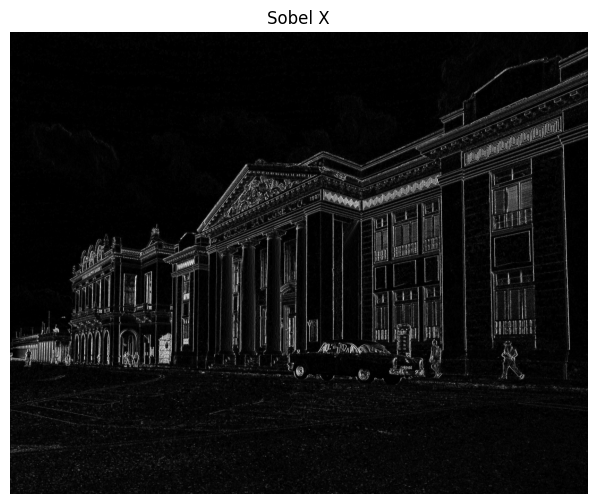

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.show()

In [25]:
start = time.perf_counter()

sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_y = np.absolute(sobel_y)
sobel_y = np.uint8(np.clip(sobel_y, 0, 255))

sobel_y_time = time.perf_counter() - start

print("Sobel Y filtering completed.")
print("Time taken:", sobel_y_time, "seconds")

Sobel Y filtering completed.
Time taken: 0.13863782299995364 seconds


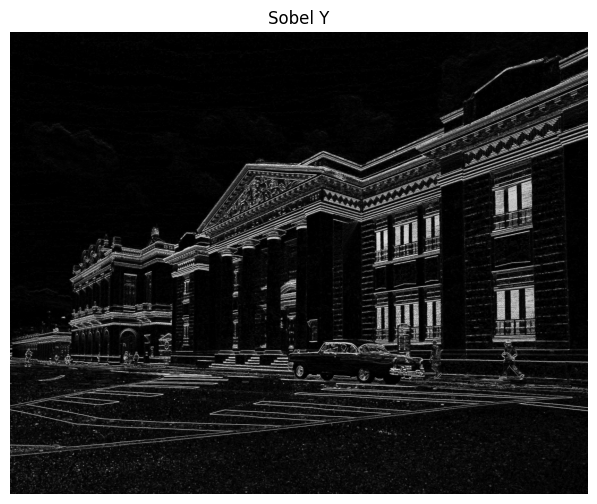

In [26]:
plt.figure(figsize=(8, 6))

plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.show()

In [27]:
sobel_x_float = sobel_x.astype(np.float32)
sobel_y_float = sobel_y.astype(np.float32)

sobel_magnitude = cv2.magnitude(sobel_x_float, sobel_y_float)
sobel_magnitude = np.uint8(np.clip(sobel_magnitude, 0, 255))

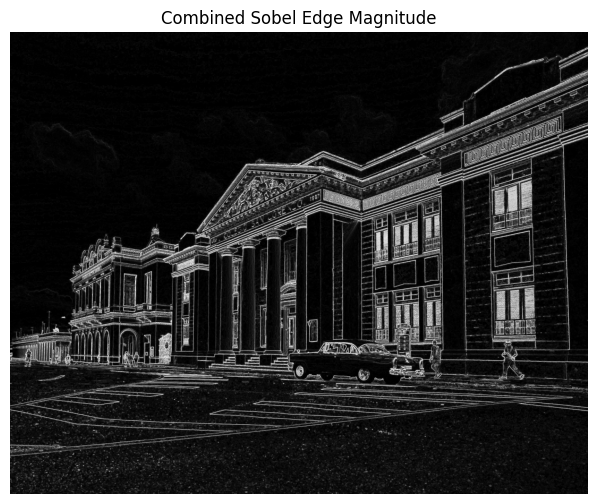

In [28]:
plt.figure(figsize=(8, 6))

plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Combined Sobel Edge Magnitude")
plt.axis("off")

plt.show()

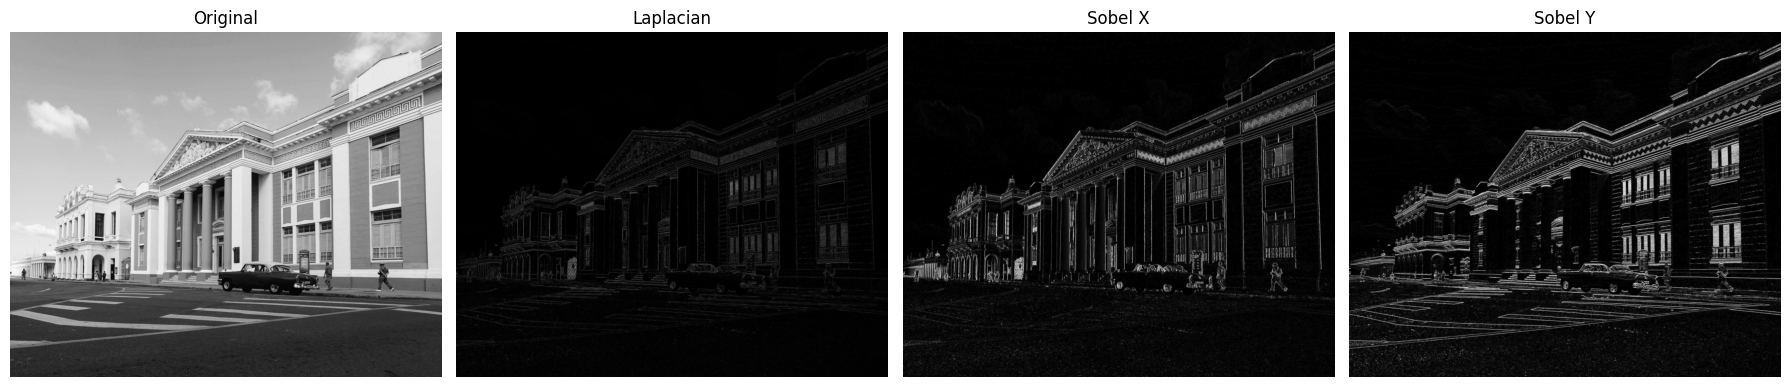

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(laplacian, cmap="gray")
axes[1].set_title("Laplacian")
axes[1].axis("off")

axes[2].imshow(sobel_x, cmap="gray")
axes[2].set_title("Sobel X")
axes[2].axis("off")

axes[3].imshow(sobel_y, cmap="gray")
axes[3].set_title("Sobel Y")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [30]:
filter_names = [
    "Gaussian",
    "Median",
    "Average",
    "Laplacian",
    "Sobel X",
    "Sobel Y"
]

filter_times = [
    gaussian_time,
    median_time,
    average_time,
    laplacian_time,
    sobel_x_time,
    sobel_y_time
]

for name, t in zip(filter_names, filter_times):
    print(f"{name:12s}: {t:.6f} seconds")

Gaussian    : 0.027050 seconds
Median      : 0.025131 seconds
Average     : 0.019981 seconds
Laplacian   : 0.216799 seconds
Sobel X     : 0.140177 seconds
Sobel Y     : 0.138638 seconds


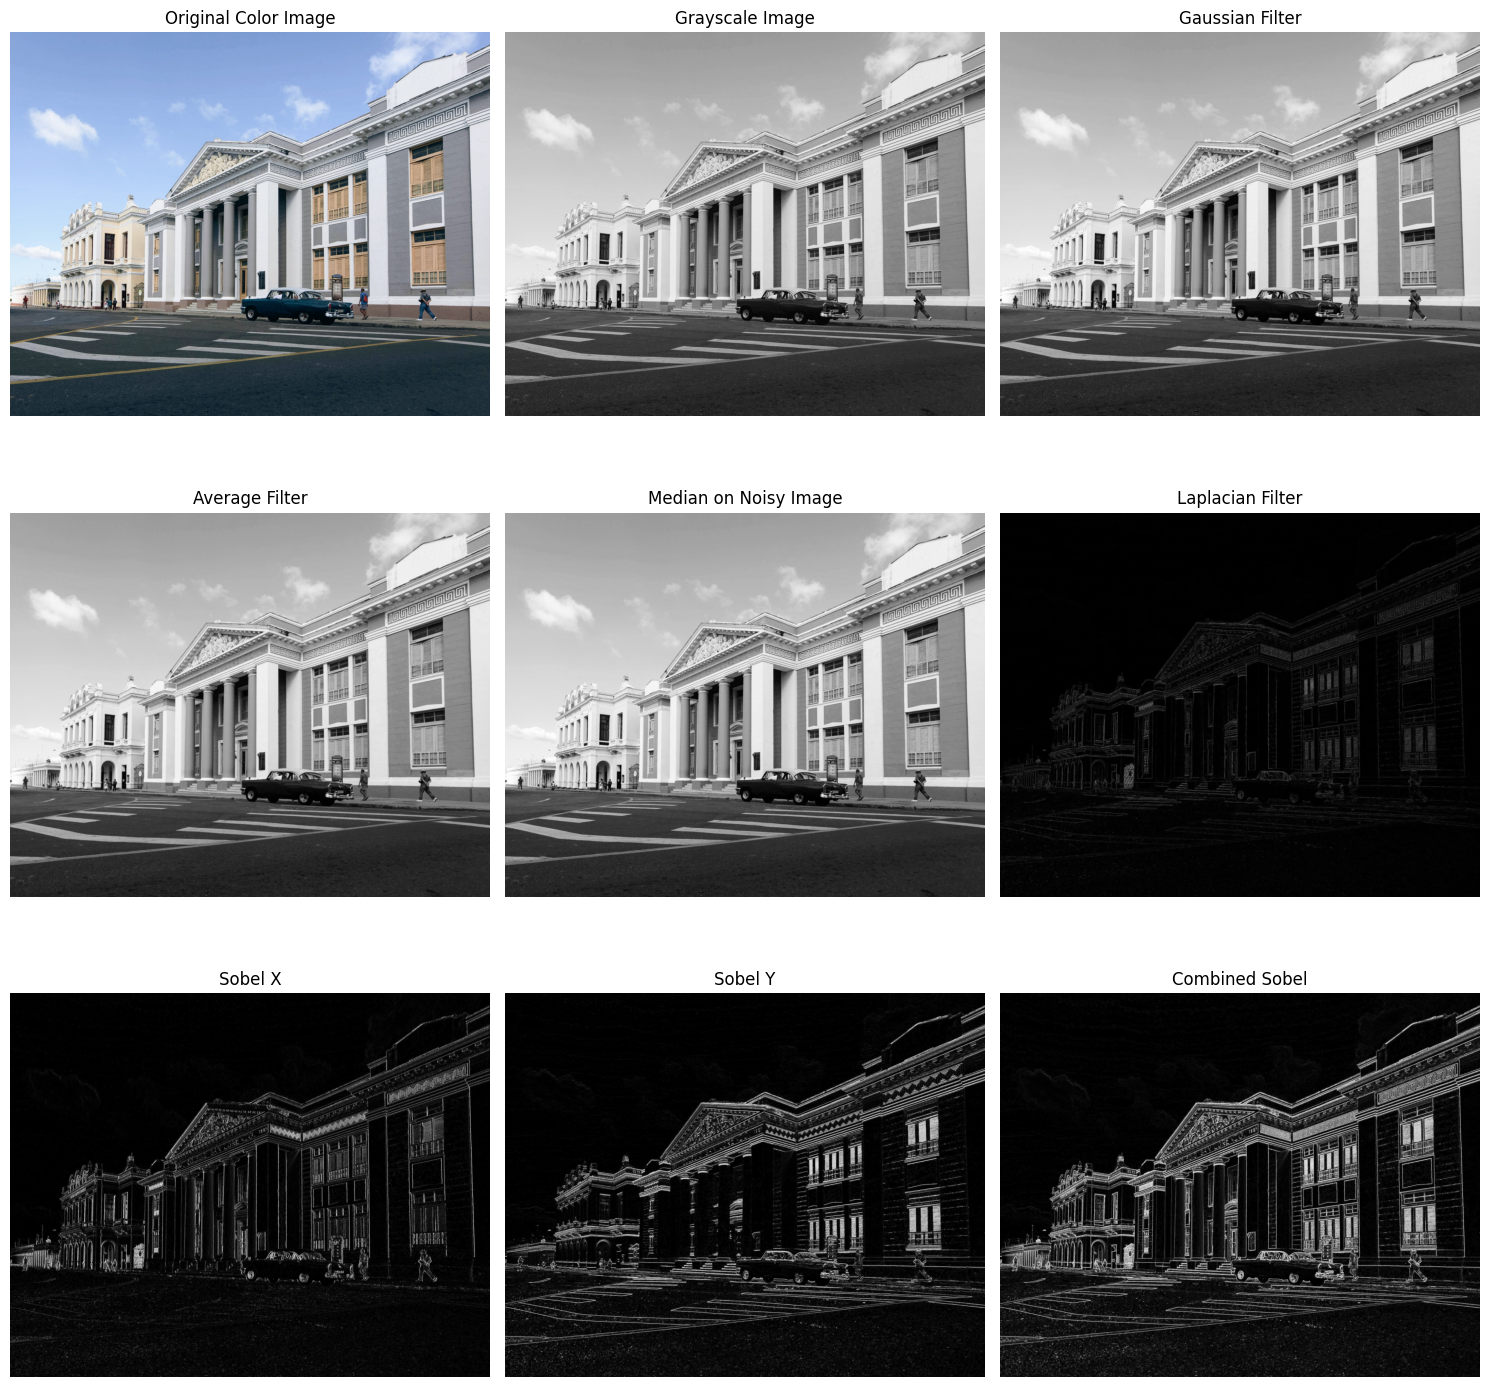

In [31]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

axes[0, 0].imshow(original_rgb)
axes[0, 0].set_title("Original Color Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(gray, cmap="gray")
axes[0, 1].set_title("Grayscale Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(gaussian, cmap="gray")
axes[0, 2].set_title("Gaussian Filter")
axes[0, 2].axis("off")

axes[1, 0].imshow(average, cmap="gray")
axes[1, 0].set_title("Average Filter")
axes[1, 0].axis("off")

axes[1, 1].imshow(median_noisy, cmap="gray")
axes[1, 1].set_title("Median on Noisy Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(laplacian, cmap="gray")
axes[1, 2].set_title("Laplacian Filter")
axes[1, 2].axis("off")

axes[2, 0].imshow(sobel_x, cmap="gray")
axes[2, 0].set_title("Sobel X")
axes[2, 0].axis("off")

axes[2, 1].imshow(sobel_y, cmap="gray")
axes[2, 1].set_title("Sobel Y")
axes[2, 1].axis("off")

axes[2, 2].imshow(sobel_magnitude, cmap="gray")
axes[2, 2].set_title("Combined Sobel")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

In [32]:
cv2.imwrite("/content/original_gray.png", gray)
cv2.imwrite("/content/gaussian_filter.png", gaussian)
cv2.imwrite("/content/average_filter.png", average)
cv2.imwrite("/content/median_filter.png", median)
cv2.imwrite("/content/noisy_image.png", noisy)
cv2.imwrite("/content/median_noisy.png", median_noisy)
cv2.imwrite("/content/laplacian_filter.png", laplacian)
cv2.imwrite("/content/sobel_x.png", sobel_x)
cv2.imwrite("/content/sobel_y.png", sobel_y)
cv2.imwrite("/content/sobel_magnitude.png", sobel_magnitude)

print("All result images saved successfully!")

All result images saved successfully!


Name - Alok Kumar Mavi

Section - B, Roll.No. 05

CU ID - CU240251681

##Questions

**1. What is spatial filtering? How is it used in digital image processing?**

**Answer:** Spatial filtering is a technique in which the value of a pixel is modified using the values of its neighboring pixels. A small matrix called a filter or kernel is moved over the image to perform operations such as smoothing, noise reduction, sharpening, and edge detection.

**2. Differentiate between Low-Pass Filters and High-Pass Filters with suitable examples.**

**Answer:** Low-pass filters smooth an image by reducing noise and rapid intensity changes. Examples include the Average, Gaussian, and Median filters. High-pass filters emphasize edges, fine details, and sudden intensity changes. Examples include the Laplacian and Sobel filters.

**3. Compare Average Filter, Gaussian Filter, and Median Filter based on their working principles and applications.**

**Answer:** The Average Filter replaces a pixel with the mean of its neighboring pixels and is mainly used for general smoothing. The Gaussian Filter uses a weighted average in which nearby pixels have greater importance, providing smoother and more natural noise reduction. The Median Filter replaces a pixel with the median value of its neighborhood and is particularly effective for removing salt-and-pepper noise while preserving edges.

**4. Why is the Median Filter particularly effective for removing salt-and-pepper noise?**

**Answer:** Salt-and-pepper noise appears as random black and white pixels. The Median Filter replaces each pixel with the median of its neighboring values, so extreme values are rejected without being averaged into the result. Therefore, noise is removed while important edges are preserved better than with mean filtering.

**5. Explain the role of convolution kernels in spatial filtering.**

**Answer:** A convolution kernel is a small matrix of values used to process neighboring pixels. It is moved across the image, and the kernel values are multiplied with corresponding pixel values and combined to produce a new pixel value. Different kernels perform different operations such as smoothing, sharpening, and edge detection.

**6. What is the purpose of the Sobel and Laplacian operators in edge detection?**

**Answer:** The Sobel operator detects intensity gradients in horizontal and vertical directions, making it useful for identifying edges and their orientations. The Laplacian operator detects rapid changes in intensity in all directions and is mainly used to enhance edges and fine details.

**7. Why are filtering operations considered an essential preprocessing step in computer vision?**

**Answer:** Filtering helps improve image quality before further processing. It can remove noise, smooth unwanted variations, enhance edges, and preserve important features. This makes later tasks such as object detection, segmentation, and feature extraction more reliable.

**8. Discuss the trade-off between image smoothing and edge preservation during filtering.**

**Answer:** Increasing image smoothing reduces noise and unwanted variations, but excessive smoothing can blur edges and remove important details. Filters such as Gaussian filtering provide controlled smoothing, while Median Filtering can remove noise while preserving edges better. Therefore, the filter and its parameters should be selected according to the application's requirements.

**9. Mention four real-world applications where spatial filtering techniques are widely used.**

**Answer:** Four important applications are medical imaging, surveillance systems, remote sensing, and autonomous vehicles. Spatial filtering is used in these applications for noise reduction, image enhancement, edge detection, and feature extraction.

**10. Compare spatial domain filtering with frequency domain filtering in terms of implementation and practical applications.**

**Answer:** Spatial domain filtering operates directly on image pixels using kernels and is generally simple to implement for tasks such as smoothing and edge detection. Frequency domain filtering first transforms the image into the frequency domain and modifies its frequency components before converting it back. Spatial filtering is commonly preferred for straightforward local image processing, while frequency domain filtering is useful for analyzing and controlling different frequency components of an image.
